# Member 02: Exploratory Data Analysis & Data Preprocessing
**AWS-Based Customer Churn Prediction System**  
**Dataset**: Cell2Cell Telecom Dataset (~71,000 customer records)  
**Author**: Member 02 Team  

---
### Pipeline Scope & Responsibilities
1. **Exploratory Data Analysis (EDA)**: Assess dataset dimensions, check target variable balance (`Churn`), identify missing value patterns, and uncover key churn drivers.
2. **Data Cleaning**: Handle missing values, resolve mixed data types (e.g. `HandsetPrice`), and deduplicate records.
3. **Preprocessing & Feature Encoding**: Transform categorical and binary features, encode multi-class variables, and preserve keys (`CustomerID`, `ServiceArea`) for Athena analytics.
4. **Train-Holdout Schema Synchronization**: Ensure strict schema and feature order alignment between `cell2celltrain_clean.csv` and `cell2cellholdout_clean.csv`.
5. **AWS Cloud Integration**: Integrate with Amazon S3 (`raw/real/` -> `processed/real/`) under Member 02 least-privilege IAM permissions.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.figsize'] = (10, 5)
%matplotlib inline

print(f"Pandas version: {pd.__version__}")

Pandas version: 2.3.3


## 1. Load Raw Datasets from S3 / Local Repository
We ingest both the training dataset (`cell2celltrain.csv`) and the unlabelled evaluation dataset (`cell2cellholdout.csv`).

In [2]:
train_df = pd.read_csv('../datasets/cell2celltrain.csv')
holdout_df = pd.read_csv('../datasets/cell2cellholdout.csv')

print(f"Train dataset shape:   {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"Holdout dataset shape: {holdout_df.shape[0]:,} rows x {holdout_df.shape[1]} columns")

Train dataset shape:   51,047 rows x 58 columns
Holdout dataset shape: 20,000 rows x 58 columns


## 2. Exploratory Data Analysis (EDA)
### 2.1 Target Variable (`Churn`) Class Distribution

C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_3852\4076898251.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_df, palette=['#2E86AB', '#E84855'], ax=ax[1])


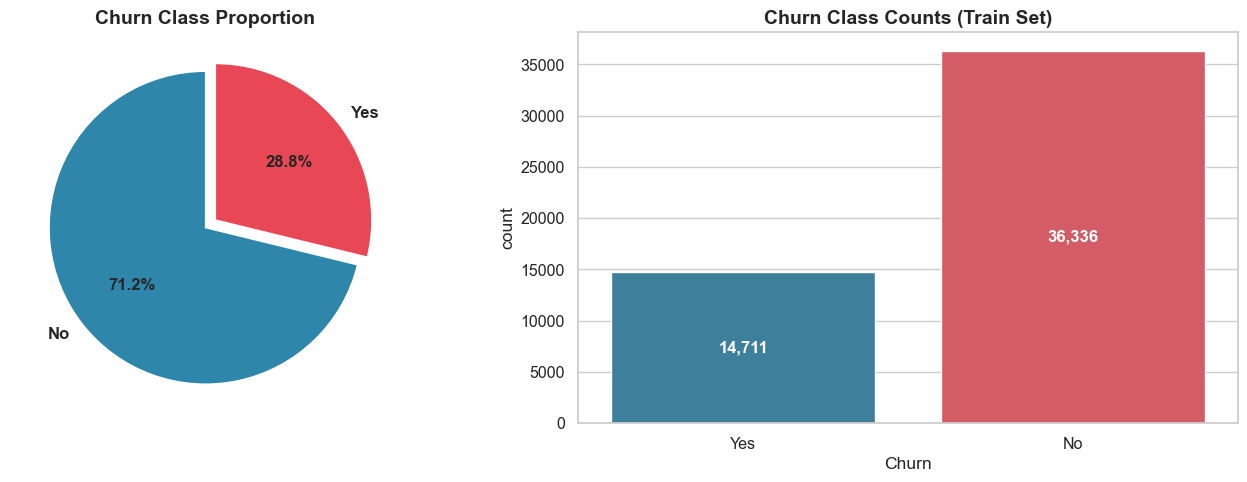

Retained (No): 36,336 (71.18%)
Churned (Yes): 14,711 (28.82%)
Imbalance Ratio: 2.47 : 1


In [3]:
churn_counts = train_df['Churn'].value_counts(dropna=False)
churn_pct = train_df['Churn'].value_counts(normalize=True, dropna=False) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
train_df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2E86AB', '#E84855'],
                                         explode=[0, 0.08], startangle=90, ax=ax[0],
                                         textprops={'fontsize': 12, 'fontweight': 'bold'})
ax[0].set_title('Churn Class Proportion', fontsize=14, fontweight='bold')
ax[0].set_ylabel('')

sns.countplot(x='Churn', data=train_df, palette=['#2E86AB', '#E84855'], ax=ax[1])
ax[1].set_title('Churn Class Counts (Train Set)', fontsize=14, fontweight='bold')
for p in ax[1].patches:
    height = p.get_height()
    ax[1].annotate(f'{int(height):,}', (p.get_x() + p.get_width()/2., height/2),
                   ha='center', va='center', color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Retained (No): {churn_counts['No']:,} ({churn_pct['No']:.2f}%)")
print(f"Churned (Yes): {churn_counts['Yes']:,} ({churn_pct['Yes']:.2f}%)")
print(f"Imbalance Ratio: {churn_counts['No']/churn_counts['Yes']:.2f} : 1")

### 2.2 Missing Value Analysis

Features with missing values:


,Missing Count,Missing %
AgeHH2,909,1.780712
AgeHH1,909,1.780712
PercChangeRevenues,367,0.718945
PercChangeMinutes,367,0.718945
MonthlyRevenue,156,0.305601
MonthlyMinutes,156,0.305601
RoamingCalls,156,0.305601
OverageMinutes,156,0.305601
DirectorAssistedCalls,156,0.305601
TotalRecurringCharge,156,0.305601


C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_3852\3924902114.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='viridis')


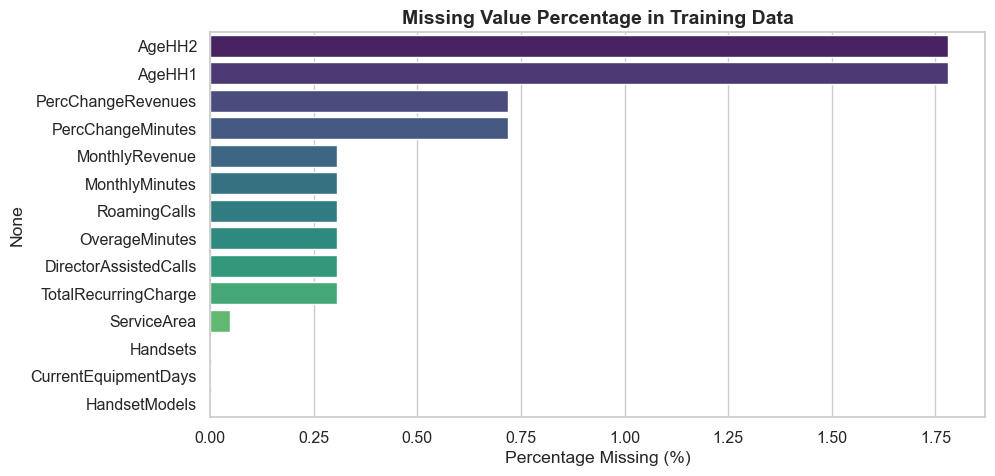

In [4]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train_df)) * 100

missing_table = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Features with missing values:")
display(missing_table)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='viridis')
plt.title('Missing Value Percentage in Training Data', fontsize=14, fontweight='bold')
plt.xlabel('Percentage Missing (%)')
plt.show()

### 2.3 Key Drivers & Feature Distributions

C:\Users\EL GHANDOUR\AppData\Local\Temp\ipykernel_3852\3616767051.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='CurrentEquipmentDays', data=train_df, palette=['#2E86AB', '#E84855'], ax=ax[0])


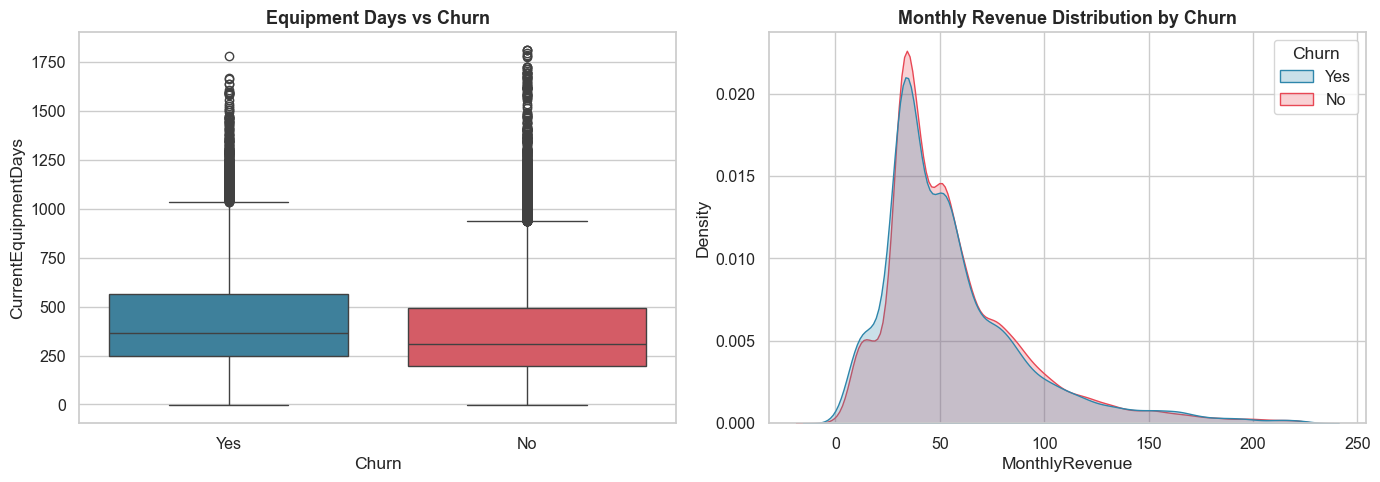

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Equipment Days vs Churn
sns.boxplot(x='Churn', y='CurrentEquipmentDays', data=train_df, palette=['#2E86AB', '#E84855'], ax=ax[0])
ax[0].set_title('Equipment Days vs Churn', fontsize=13, fontweight='bold')

# Monthly Revenue vs Churn (<99th percentile)
q99 = train_df['MonthlyRevenue'].quantile(0.99)
sns.kdeplot(data=train_df[train_df['MonthlyRevenue'] < q99], x='MonthlyRevenue', hue='Churn',
            fill=True, common_norm=False, palette=['#2E86AB', '#E84855'], ax=ax[1])
ax[1].set_title('Monthly Revenue Distribution by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data Cleaning and Preprocessing Pipeline
We employ the production preprocessor `Cell2CellPreprocessor` developed in `member02/preprocess.py`.

In [6]:
sys.path.append('..')
from member02.preprocess import Cell2CellPreprocessor

preprocessor = Cell2CellPreprocessor()
clean_train = preprocessor.fit_transform(train_df)
clean_holdout = preprocessor.transform_holdout(holdout_df)

print("--- Transformation Summary ---")
print(f"Clean Train Shape:   {clean_train.shape}")
print(f"Clean Holdout Shape: {clean_holdout.shape}")
print(f"Null values in clean train:   {clean_train.isnull().sum().sum()}")
print(f"Null values in clean holdout: {clean_holdout.drop(columns=['Churn']).isnull().sum().sum()}")

Fitting preprocessor on training data...
--- Transformation Summary ---
Clean Train Shape:   (51047, 69)
Clean Holdout Shape: (20000, 69)
Null values in clean train:   0
Null values in clean holdout: 0


## 4. Verification and Export
Verify column consistency and preview final cleaned data frames.

In [7]:
assert list(clean_train.columns) == list(clean_holdout.columns), "Columns do not match!"
print(f"Verified: Exactly {len(clean_train.columns)} identical columns in both datasets!")
display(clean_train.head(5))

Verified: Exactly 69 identical columns in both datasets!


,CustomerID,ServiceArea,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes,Churn
0,3000002,SEAPOR503,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,0,1,0,0,0,1,0,0,1
1,3000010,PITHOM412,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,0,1,0,0,0,0,0,1,1
2,3000014,MILMIL414,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,0,0,0,0,0,0,0,1,0
3,3000022,PITHOM412,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,1,0,0,0,0,1,0,0,0
4,3000026,OKCTUL918,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,0,1,0,0,0,0,0,1,1
